
# Mini‑Lab: Embeddings e Vetores com BERT (e Sentence‑BERT) — Busca Semântica no Colab

Este notebook foi desenhado para **introduzir embeddings** (vetores) baseados em **BERT** de forma prática: vamos construir um **buscador semântico** (“Google interno”) para um conjunto de textos.

Você vai aprender, passo a passo:

- O que é um **embedding** e por que ele é um **vetor**.
- Como comparar vetores com **similaridade cosseno**.
- Como gerar embeddings usando:
  1) **TF‑IDF** (baseline)
  2) **BERT “puro”** (via `transformers`, com *pooling* simples)
  3) **Sentence‑BERT (SBERT)** (via `sentence-transformers`, modelo treinado para similaridade)
- Como visualizar vetores em 2D com **t‑SNE**.
- Um mini‑desafio e métricas simples (top‑k).

> **Dica didática:** execute as células na ordem. As seções têm explicação + código + exercícios.



## 0) Pré‑requisitos (conceitos mínimos)

### 0.1 Vetores (bem direto)
Um **vetor** é uma lista de números, por exemplo:

\begin{align}
\mathbf{v} = [0.2,\ -1.3,\ 0.7]
\end{align}

Em embeddings, esse vetor costuma ter **centenas de dimensões** (ex.: 384, 768, 1024...).  
Cada dimensão pode ser vista como um “sinal” que ajuda a representar significado.

### 0.2 Similaridade cosseno (a principal ferramenta do lab)

A similaridade cosseno mede o “alinhamento” entre dois vetores:

\begin{align}
\cos(\theta) \;=\; \frac{\mathbf{a}\cdot\mathbf{b}}{\|\mathbf{a}\|\;\|\mathbf{b}\|}
\end{align}

- $(\mathbf{a}\cdot\mathbf{b})$ é o **produto escalar** (multiplica e soma elemento a elemento).
- $(\|\mathbf{a}\|)$ é a **norma** (tamanho) do vetor:

\begin{align}
||\mathbf{a}\|=\sqrt{\sum_i a_i^2}
\end{align}

**Interpretação rápida:**
- `1.0` → vetores muito parecidos (mesma direção)
- `0.0` → sem relação (ortogonais)
- `-1.0` → sentidos opostos (raro em embeddings de sentenças, mas possível)

Neste notebook, **o buscador** funciona assim:

1. Transformar cada texto em um vetor (embedding).
2. Transformar a consulta em um vetor.
3. Calcular a similaridade cosseno entre a consulta e todos os textos.
4. Retornar os `top‑k` textos com maior similaridade.



## 1) Instalação de bibliotecas (Colab)

Vamos usar:
- `scikit-learn` para TF‑IDF, cosine similarity e t‑SNE
- `transformers` para BERT
- `sentence-transformers` para SBERT
- `torch` para rodar os modelos


In [8]:
!pip -q install -U scikit-learn transformers sentence-transformers accelerate


[notice] A new release of pip is available: 24.3.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2) Imports e utilitários

In [9]:
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt

import torch
from transformers import AutoTokenizer, AutoModel

from sentence_transformers import SentenceTransformer


### 2.1 Funções utilitárias: normalização, ranking e impressão

In [10]:
def l2_norm(v: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    # Normaliza vetores para norma 1 (L2). Ajuda a estabilizar cosine similarity.
    denom = np.linalg.norm(v, axis=-1, keepdims=True)
    return v / np.maximum(denom, eps)

def top_k_similar(query_vec: np.ndarray, matrix_vecs: np.ndarray, k: int = 5):
    # Retorna índices e scores dos k mais similares via cosine similarity.
    sims = cosine_similarity(query_vec.reshape(1, -1), matrix_vecs).flatten()
    idx = np.argsort(-sims)[:k]
    return idx, sims[idx]

def show_results(query: str, texts: list[str], idx: np.ndarray, scores: np.ndarray, title: str):
    print("=" * 90)
    print(title)
    print(f"QUERY: {query}\n")
    for rank, (i, s) in enumerate(zip(idx, scores), start=1):
        print(f"[{rank}] score={s:.4f}  |  id={i}")
        print(f"    {texts[i]}")
        print("-" * 90)



## 3) Dataset pequeno (editável)

Abaixo há um conjunto de textos curtos em português (misturando tecnologia, saúde, viagens, culinária etc.).
Você pode:
- aumentar/reduzir a lista
- trocar por FAQs reais
- usar parágrafos de um documento interno (com cuidado com privacidade)

**Importante para a aula:** comece com 20–40 itens para rodar rápido e visualizar bem.


In [11]:
texts = [
    "O Kubernetes organiza aplicações em contêineres usando pods e namespaces.",
    "BERT é um modelo de linguagem baseado em Transformers com atenção bidirecional.",
    "TF-IDF representa textos como vetores esparsos de termos com pesos.",
    "O Keycloak é uma solução de identidade para autenticação e single sign-on (SSO).",
    "Uma rede neural pode aprender representações úteis para classificação de texto.",
    "Esteatose hepática é o acúmulo de gordura no fígado e pode ser associada a obesidade.",
    "Exercícios físicos regulares ajudam a melhorar a saúde cardiovascular.",
    "Uma dieta balanceada inclui proteínas, carboidratos, fibras e gorduras saudáveis.",
    "Em Paris, o metrô e o RER conectam pontos turísticos e regiões metropolitanas.",
    "Em Budapeste, os banhos termais são uma atração tradicional muito conhecida.",
    "A culinária francesa inclui pratos como confit de pato e magret de pato.",
    "O t-SNE projeta dados de alta dimensão para 2D preservando vizinhanças locais.",
    "Embeddings transformam texto em vetores densos que capturam semântica.",
    "Similaridade cosseno mede o alinhamento entre dois vetores.",
    "O SharePoint Online permite criar sites, listas e páginas para intranet corporativa.",
    "Power Automate automatiza fluxos de trabalho integrando serviços do Microsoft 365.",
    "Uma VPN cria um túnel criptografado para acessar recursos internos remotamente.",
    "RAG combina recuperação de documentos com geração de texto por LLMs.",
    "O MinIO é um storage compatível com S3 para objetos.",
    "Milvus é um banco de dados vetorial para busca por similaridade.",
    "O GitHub Actions executa pipelines de CI/CD para build e deploy.",
    "A normalização L2 ajusta vetores para terem norma 1.",
    "O produto escalar soma multiplicações elemento a elemento entre dois vetores.",
    "Uma eSIM permite usar planos móveis sem um chip físico tradicional.",
    "Um fone com cancelamento de ruído reduz sons externos usando processamento de sinal.",
    "Um condomínio possui área privativa e área de uso comum em sua composição.",
    "O risco de duplicação de eventos pode ser evitado guardando IDs em uma planilha.",
    "O termo underfitting indica um modelo simples demais para capturar padrões.",
    "A técnica de mean pooling tira a média dos embeddings dos tokens de uma frase.",
    "O token [CLS] pode ser usado como representação agregada em modelos BERT.",
]

df = pd.DataFrame({"id": range(len(texts)), "text": texts})
df.head()


,id,text
0,0,O Kubernetes organiza aplicações em contêinere...
1,1,BERT é um modelo de linguagem baseado em Trans...
2,2,TF-IDF representa textos como vetores esparsos...
3,3,O Keycloak é uma solução de identidade para au...
4,4,Uma rede neural pode aprender representações ú...



## 4) Baseline 1: TF‑IDF + Similaridade Cosseno

### 4.1 Intuição do TF‑IDF (bem direto)

- **TF (Term Frequency)**: quantas vezes um termo aparece no documento.
- **IDF (Inverse Document Frequency)**: reduz o peso de termos muito comuns.

Resultado: cada texto vira um vetor com uma dimensão por termo do vocabulário.
Esses vetores costumam ser **esparsos** (muitos zeros), porque um documento usa poucos termos do total.

### 4.2 Vamos criar o “buscador TF‑IDF”


In [12]:
tfidf = TfidfVectorizer(lowercase=True)
X_tfidf = tfidf.fit_transform(texts)  # matriz (n_textos, vocab_size)
X_tfidf.shape


(30, 225)

In [13]:
def search_tfidf(query: str, k: int = 5):
    q_vec = tfidf.transform([query])
    sims = cosine_similarity(q_vec, X_tfidf).flatten()
    idx = np.argsort(-sims)[:k]
    return idx, sims[idx]

query_examples = [
    "como comparar vetores?",
    "o que é SSO e autenticação?",
    "quero buscar por banco de dados vetorial",
    "atrações em Budapeste",
    "prato francês com pato",
]

for q in query_examples:
    idx, scores = search_tfidf(q, k=3)
    show_results(q, texts, idx, scores, title="TF‑IDF Search")


TF‑IDF Search
QUERY: como comparar vetores?

[1] score=0.3623  |  id=2
    TF-IDF representa textos como vetores esparsos de termos com pesos.
------------------------------------------------------------------------------------------
[2] score=0.2046  |  id=29
    O token [CLS] pode ser usado como representação agregada em modelos BERT.
------------------------------------------------------------------------------------------
[3] score=0.1922  |  id=21
    A normalização L2 ajusta vetores para terem norma 1.
------------------------------------------------------------------------------------------
TF‑IDF Search
QUERY: o que é SSO e autenticação?

[1] score=0.3881  |  id=3
    O Keycloak é uma solução de identidade para autenticação e single sign-on (SSO).
------------------------------------------------------------------------------------------
[2] score=0.2135  |  id=12
    Embeddings transformam texto em vetores densos que capturam semântica.
-----------------------------------------


### 4.3 Discussão: onde TF‑IDF falha?

TF‑IDF depende muito de **palavras iguais**.
Se a consulta usa sinônimos/paráfrases, pode falhar.

**Exemplo:** "banco vetorial" vs "vector database" vs "busca por similaridade".

> É aí que embeddings densos (BERT/SBERT) costumam ser melhores: eles tentam capturar **significado**, não apenas palavras.



## 5) Embeddings com BERT “puro” (via Transformers)

Aqui vamos usar um modelo `bert-base-multilingual-cased` (multilíngue) para gerar embeddings.

### 5.1 Tokenização e saída do BERT

O BERT recebe tokens e retorna, para cada token, um vetor (embedding) de dimensão `hidden_size` (ex.: 768).

Saída típica:
- `last_hidden_state`: matriz de forma `(batch, seq_len, hidden_size)`

Mas nós queremos **um vetor por sentença**. Então precisamos de um *pooling*.

### 5.2 Pooling: duas opções simples

**(A) CLS pooling**  
Pegar o vetor do token especial `[CLS]` (primeiro token).

\begin{align}
$\text{sent}_{vec} = \mathbf{h}_{CLS}$
\end{align}

**(B) Mean pooling**  
Fazer a média dos vetores dos tokens (ignorando padding):

\begin{align}
$\text{sent}_{vec} = \frac{1}{m}\sum_{i=1}^{m}\mathbf{h}_i$
\end{align}

onde \(m\) é o número de tokens “reais” (sem padding).

> Observação importante: BERT “puro” nem sempre é ótimo para similaridade de sentenças sem treino específico.
Mas é excelente para ensinar *como a mágica é construída*.


In [14]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device


'cpu'

In [15]:
bert_model_name = "bert-base-multilingual-cased"

tokenizer = AutoTokenizer.from_pretrained(bert_model_name)
bert = AutoModel.from_pretrained(bert_model_name).to(device)
bert.eval()

print("Loaded:", bert_model_name)


\\wsl$\Ubuntu\home\guilherme\projetos\disciplinas\.venv\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Guilherme\.cache\huggingface\hub\models--bert-base-multilingual-cased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5019.19it/s]
[transformer

Loaded: bert-base-multilingual-cased


### 5.3 Funções de embedding com CLS e Mean pooling

In [16]:
@torch.no_grad()
def bert_encode(text_list: list[str], pooling: str = "mean", max_length: int = 64, batch_size: int = 16) -> np.ndarray:
    # Gera embeddings por sentença usando BERT + pooling.
    # pooling: 'cls' ou 'mean'
    all_vecs = []
    for start in range(0, len(text_list), batch_size):
        batch = text_list[start:start+batch_size]
        enc = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        ).to(device)

        out = bert(**enc)  # last_hidden_state: (B, L, H)
        last_hidden = out.last_hidden_state

        if pooling == "cls":
            sent_vec = last_hidden[:, 0, :]  # (B, H)
        elif pooling == "mean":
            mask = enc["attention_mask"].unsqueeze(-1).type_as(last_hidden)  # (B, L, 1)
            summed = (last_hidden * mask).sum(dim=1)                         # (B, H)
            counts = mask.sum(dim=1).clamp(min=1e-9)                         # (B, 1)
            sent_vec = summed / counts                                       # (B, H)
        else:
            raise ValueError("pooling must be 'cls' or 'mean'")

        all_vecs.append(sent_vec.cpu().numpy())

    return np.vstack(all_vecs)

X_bert_cls = bert_encode(texts, pooling="cls")
X_bert_mean = bert_encode(texts, pooling="mean")

X_bert_cls.shape, X_bert_mean.shape


((30, 768), (30, 768))

### 5.4 Buscador BERT (CLS vs Mean)

In [17]:
X_bert_cls_n = l2_norm(X_bert_cls)
X_bert_mean_n = l2_norm(X_bert_mean)

def search_bert(query: str, X: np.ndarray, pooling_name: str, k: int = 5):
    # Para a query, mean pooling costuma ser mais estável
    q_vec = bert_encode([query], pooling="mean")[0]
    q_vec = l2_norm(q_vec.reshape(1, -1))[0]
    idx, scores = top_k_similar(q_vec, X, k=k)
    show_results(query, texts, idx, scores, title=f"BERT Search ({pooling_name})")

for q in query_examples:
    search_bert(q, X_bert_cls_n, "CLS", k=3)
    search_bert(q, X_bert_mean_n, "MEAN", k=3)


BERT Search (CLS)
QUERY: como comparar vetores?

[1] score=0.3000  |  id=22
    O produto escalar soma multiplicações elemento a elemento entre dois vetores.
------------------------------------------------------------------------------------------
[2] score=0.2676  |  id=13
    Similaridade cosseno mede o alinhamento entre dois vetores.
------------------------------------------------------------------------------------------
[3] score=0.2621  |  id=21
    A normalização L2 ajusta vetores para terem norma 1.
------------------------------------------------------------------------------------------
BERT Search (MEAN)
QUERY: como comparar vetores?

[1] score=0.6201  |  id=22
    O produto escalar soma multiplicações elemento a elemento entre dois vetores.
------------------------------------------------------------------------------------------
[2] score=0.5942  |  id=13
    Similaridade cosseno mede o alinhamento entre dois vetores.
-----------------------------------------------------


### 5.5 Exercício rápido

1) Teste uma consulta com sinônimos, por exemplo:
- "banco vetorial"
- "vector database"
- "busca por similaridade"

2) Compare TF‑IDF vs BERT (CLS/MEAN).  
Anote:
- Qual retornou itens mais “semânticos”?
- Qual pareceu preso às palavras exatas?



## 6) Embeddings com Sentence‑BERT (SBERT) — o jeito “certo” para similaridade

**Sentence‑BERT** é uma família de modelos treinados para produzir embeddings de sentenças que funcionam bem com cosine similarity.

Aqui vamos usar um modelo multilíngue leve:

- `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2`

Ele costuma produzir vetores de dimensão 384.

### 6.1 Por que SBERT costuma funcionar melhor?

Porque foi treinado para que:
- sentenças com mesmo significado tenham vetores próximos
- sentenças diferentes fiquem mais afastadas


In [18]:
sbert_model_name = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
sbert = SentenceTransformer(sbert_model_name, device=device)

X_sbert = sbert.encode(texts, convert_to_numpy=True, normalize_embeddings=True)
X_sbert.shape


\\wsl$\Ubuntu\home\guilherme\projetos\disciplinas\.venv\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Guilherme\.cache\huggingface\hub\models--sentence-transformers--paraphrase-multilingual-MiniLM-L12-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 199/199 [00:00<

(30, 384)

In [19]:
def search_sbert(query: str, k: int = 5):
    q_vec = sbert.encode([query], convert_to_numpy=True, normalize_embeddings=True)[0]
    idx, scores = top_k_similar(q_vec, X_sbert, k=k)
    show_results(query, texts, idx, scores, title=f"SBERT Search ({sbert_model_name})")

for q in query_examples:
    search_sbert(q, k=3)


SBERT Search (sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2)
QUERY: como comparar vetores?

[1] score=0.6416  |  id=13
    Similaridade cosseno mede o alinhamento entre dois vetores.
------------------------------------------------------------------------------------------
[2] score=0.4292  |  id=19
    Milvus é um banco de dados vetorial para busca por similaridade.
------------------------------------------------------------------------------------------
[3] score=0.4059  |  id=22
    O produto escalar soma multiplicações elemento a elemento entre dois vetores.
------------------------------------------------------------------------------------------
SBERT Search (sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2)
QUERY: o que é SSO e autenticação?

[1] score=0.7163  |  id=3
    O Keycloak é uma solução de identidade para autenticação e single sign-on (SSO).
------------------------------------------------------------------------------------------
[2] score=0.


## 7) Comparação rápida: TF‑IDF vs BERT vs SBERT

Vamos fazer uma função que roda as três abordagens para uma única query e compara lado a lado.


In [20]:
def compare_all(query: str, k: int = 5):
    print("\n" + "#"*100)
    print(f"QUERY: {query}")
    print("#"*100 + "\n")

    idx, scores = search_tfidf(query, k=k)
    show_results(query, texts, idx, scores, title="TF‑IDF")

    q_vec = bert_encode([query], pooling="mean")[0]
    q_vec = l2_norm(q_vec.reshape(1, -1))[0]

    idx, scores = top_k_similar(q_vec, X_bert_cls_n, k=k)
    show_results(query, texts, idx, scores, title="BERT (CLS)")

    idx, scores = top_k_similar(q_vec, X_bert_mean_n, k=k)
    show_results(query, texts, idx, scores, title="BERT (MEAN)")

    q_vec = sbert.encode([query], convert_to_numpy=True, normalize_embeddings=True)[0]
    idx, scores = top_k_similar(q_vec, X_sbert, k=k)
    show_results(query, texts, idx, scores, title="SBERT")

compare_all("quero saber sobre busca por similaridade em banco vetorial", k=4)



####################################################################################################
QUERY: quero saber sobre busca por similaridade em banco vetorial
####################################################################################################

TF‑IDF
QUERY: quero saber sobre busca por similaridade em banco vetorial

[1] score=0.7671  |  id=19
    Milvus é um banco de dados vetorial para busca por similaridade.
------------------------------------------------------------------------------------------
[2] score=0.1473  |  id=13
    Similaridade cosseno mede o alinhamento entre dois vetores.
------------------------------------------------------------------------------------------
[3] score=0.1208  |  id=17
    RAG combina recuperação de documentos com geração de texto por LLMs.
------------------------------------------------------------------------------------------
[4] score=0.0601  |  id=0
    O Kubernetes organiza aplicações em contêineres usando pods e name


## 8) Visualização em 2D (t‑SNE)

Embeddings têm alta dimensão (384, 768...). Para “ver” padrões, projetamos para 2D.

### 8.1 Intuição simples do t‑SNE
- t‑SNE tenta manter **vizinhanças locais**: pontos que eram próximos em alta dimensão tendem a ficar próximos em 2D.
- É ótimo para ver “clusters” visuais.
- Não é perfeito (pode distorcer distâncias globais), mas é muito útil didaticamente.

Vamos visualizar os embeddings do SBERT.


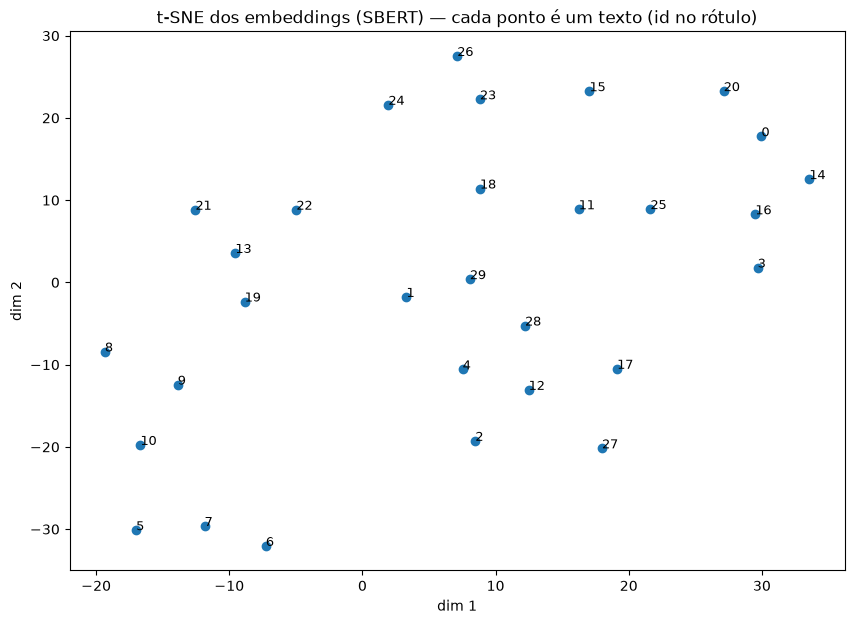

,id,text
0,0,O Kubernetes organiza aplicações em contêinere...
1,1,BERT é um modelo de linguagem baseado em Trans...
2,2,TF-IDF representa textos como vetores esparsos...
3,3,O Keycloak é uma solução de identidade para au...
4,4,Uma rede neural pode aprender representações ú...
5,5,Esteatose hepática é o acúmulo de gordura no f...
6,6,Exercícios físicos regulares ajudam a melhorar...
7,7,"Uma dieta balanceada inclui proteínas, carboid..."
8,8,"Em Paris, o metrô e o RER conectam pontos turí..."
9,9,"Em Budapeste, os banhos termais são uma atraçã..."


In [21]:
tsne = TSNE(n_components=2, perplexity=10, random_state=42, init="pca", learning_rate="auto")
Z = tsne.fit_transform(X_sbert)

plt.figure(figsize=(10, 7))
plt.scatter(Z[:, 0], Z[:, 1])

for i, _ in enumerate(texts):
    plt.text(Z[i, 0], Z[i, 1], str(i), fontsize=9)

plt.title("t-SNE dos embeddings (SBERT) — cada ponto é um texto (id no rótulo)")
plt.xlabel("dim 1")
plt.ylabel("dim 2")
plt.show()

df[["id", "text"]].head(10)



### 8.2 Exercício de visualização
1) Escolha 3–5 textos que você acha que são do mesmo tema (ex.: “infra de TI”).
2) Veja se os IDs aparecem próximos no mapa.
3) Se não aparecerem, tente:
   - aumentar `perplexity` para 15 ou 20
   - ou usar mais textos do mesmo tema



## 9) Métrica simples: Top‑k “acerto” (mini‑avaliação)

Em um cenário real, você teria um *ground truth* (quais documentos são relevantes para cada query).
Aqui vamos criar um ground truth manual bem pequeno para fins didáticos.

### 9.1 Vamos definir algumas queries e os IDs relevantes

Você pode editar:
- `eval_set`
- `relevant_ids`

**Métrica: recall@k** (bem simples):
- Para cada query, verifica se **pelo menos 1** item relevante aparece nos top‑k.


In [22]:
eval_set = [
    {"query": "o que é banco de dados vetorial e busca por similaridade?", "relevant_ids": {19, 13, 17}},
    {"query": "pratos franceses com pato", "relevant_ids": {10}},
    {"query": "o que é SSO e autenticação centralizada", "relevant_ids": {3}},
    {"query": "atrações turísticas em Budapeste", "relevant_ids": {9}},
]

def recall_at_k(search_fn, k: int = 5):
    hits = 0
    for item in eval_set:
        q = item["query"]
        rel = item["relevant_ids"]
        idx, _ = search_fn(q, k=k)
        if any(i in rel for i in idx):
            hits += 1
    return hits / len(eval_set)

def tfidf_search_fn(query, k=5):
    return search_tfidf(query, k=k)

def sbert_search_fn(query, k=5):
    q_vec = sbert.encode([query], convert_to_numpy=True, normalize_embeddings=True)[0]
    idx, scores = top_k_similar(q_vec, X_sbert, k=k)
    return idx, scores

def bert_mean_search_fn(query, k=5):
    q_vec = bert_encode([query], pooling="mean")[0]
    q_vec = l2_norm(q_vec.reshape(1, -1))[0]
    idx, scores = top_k_similar(q_vec, X_bert_mean_n, k=k)
    return idx, scores

for k in [1, 3, 5]:
    print(f"k={k} | recall@k TF-IDF     = {recall_at_k(tfidf_search_fn, k=k):.2f}")
    print(f"k={k} | recall@k BERT(mean)= {recall_at_k(bert_mean_search_fn, k=k):.2f}")
    print(f"k={k} | recall@k SBERT      = {recall_at_k(sbert_search_fn, k=k):.2f}")
    print("-"*60)


k=1 | recall@k TF-IDF     = 1.00
k=1 | recall@k BERT(mean)= 1.00
k=1 | recall@k SBERT      = 1.00
------------------------------------------------------------
k=3 | recall@k TF-IDF     = 1.00
k=3 | recall@k BERT(mean)= 1.00
k=3 | recall@k SBERT      = 1.00
------------------------------------------------------------
k=5 | recall@k TF-IDF     = 1.00
k=5 | recall@k BERT(mean)= 1.00
k=5 | recall@k SBERT      = 1.00
------------------------------------------------------------



## 10) Mini‑desafio (para alunos)

### Desafio A (fácil, 15–20 min)
1) Adicione **10 textos** novos no dataset (`texts`) sobre 2 temas diferentes (ex.: “saúde” e “infra”).
2) Crie **5 queries** e um conjunto de `relevant_ids` para cada query.
3) Compare `recall@k` entre TF‑IDF e SBERT.

### Desafio B (médio, 20–30 min)
1) Teste outro modelo SBERT multilíngue (pesquise por “sentence-transformers multilingual”).
2) Compare a dimensão do embedding e a qualidade dos resultados.

### Desafio C (médio, 20–30 min)
1) Experimente normalização:
   - sem `normalize_embeddings=True` no SBERT
   - com normalização manual (`l2_norm`)
2) Veja se muda o ranking para algumas queries.

### Questões para discutir em sala
- Quando TF‑IDF pode ser suficiente?
- Por que BERT “puro” pode não ser ideal para similaridade?
- O que muda quando aumentamos o número de documentos?



## 11) Próximo passo natural: RAG (apenas contexto)

Este buscador é a parte “R” (retrieval).  
Um pipeline RAG típico faz:

1) **Busca semântica** (você já fez!)
2) Pega os top‑k textos
3) Envia esses textos como contexto para um modelo gerador responder

Mas isso fica para o próximo notebook :)
